In [18]:
# 2025.12.01 Ensemble Set1(xgb+lgb+lr+sgd+rf)_Hvoting - 돌리기

In [19]:
import sys

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [20]:
import os

import time
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics         import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics         import classification_report
from sklearn.metrics         import roc_auc_score
from sklearn.metrics         import precision_recall_curve, classification_report
from sklearn.datasets        import make_classification
from sklearn.preprocessing   import RobustScaler

# Model import
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import StackingClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.ensemble       import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.linear_model   import LinearRegression
from sklearn.linear_model   import SGDClassifier
from sklearn.svm            import SVC
from sklearn.svm            import LinearSVC
from xgboost                import XGBClassifier
from xgboost                import plot_importance
from lightgbm               import LGBMClassifier
from catboost               import CatBoostClassifier
from sklearn.ensemble       import HistGradientBoostingClassifier
from sklearn.calibration    import CalibratedClassifierCV # stacking시 LSVC 에러용

# hyperopt 용
from hyperopt               import hp

# 사용자 Functions import
import HyperParams          as HP 
import utils.data_sampling  as ds 

import importlib

from utils import user_utils
importlib.reload(user_utils)

from utils import user_utils    as uu
from utils import preprocessing as pp
from utils import data_sampling as ds
from utils import model_utils   as mu
from utils import modeling      as mo

from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [21]:
# -------------------------------------------------------
# 🔷 모델 생성 함수 (HyperOpt 파라미터 자동 적용)
# -------------------------------------------------------

def get_models():
    models = {
        "cat": CatBoostClassifier(**HP.cb_best_params),
        "dt": DecisionTreeClassifier(**HP.dt_basic_params),
        "gb": GradientBoostingClassifier(**HP.gb_best_params),
        "hgb": HistGradientBoostingClassifier(**HP.hgb_best_params),
        "lgbm": LGBMClassifier(**HP.lgbm_best_param2),
        "lr": LogisticRegression(**HP.lr_best_params),
        "lir" : LinearRegression(**HP.lir_best_params),
        "lsvc": LinearSVC(**HP.lsvc_best_params),
        "mlp": MLPClassifier(**HP.mlp_basic_params),
        "rf": RandomForestClassifier(**HP.rf_best_params),
        "sgd": SGDClassifier(**HP.sgd_best_params),
        "svm_rbf": SVC(**HP.svc_rbf_best_params),
        "xgb": XGBClassifier(**HP.xgb_best_params, eval_metric='logloss'),
    }

    return models
# eof ----------------------------------------------------------------

In [22]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [23]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [24]:
# 2. 데이터 전처리
# 2.1 Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')
X_features.shape, y_target.shape

((284807, 29), (284807,))

In [25]:
# 2.2 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [26]:
# 2.3 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [13]:
# 학습/검증 데이터 분리
# X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [37]:
# 2.4 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)


✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [3]:
# Over Sampling한 경우 학습/검증 데이터 분리
# X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

In [15]:
# 사용자 Functions import - 에러나서 다시 실행
# import importlib
# from utils import hyperopt_search
# importlib.reload(hyperopt_search)

# from utils.hyperopt_search import hyperopt_search, train_and_evaluate

In [16]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기 
# 2.5 StandardScaler 적용
X_train_sscaled, X_test_sscaled, scaler = pp.scale_data(X_train, X_test)


In [17]:
# 2.6 robustScaler 적용

rscaler = RobustScaler()
X_train_rscaled = rscaler.fit_transform(X_train)   # 학습 데이터로 fit + transform
X_test_rscaled = rscaler.transform(X_test)         # 테스트 데이터는 transform만


In [27]:
def create_lr(best_params):
    """
    LogisticRegression 모델을 HyperOpt/Optuna로 찾은 best_params 기반으로 생성하는 함수.

    이 함수는 LogisticRegression의 solver와 penalty 조합이 유효한지 검사하고,
    유효하지 않은 조합이 들어올 경우 자동으로 수정하여 안전하게 모델을 생성한다.

    Parameters
    ----------
    best_params : dict
        HyperOpt 또는 Optuna로 최적화한 LogisticRegression의 최적 파라미터 딕셔너리.
        예: {"C": 0.1, "solver": "liblinear", "penalty": "l1"}

    Returns
    -------
    LogisticRegression
        최종적으로 검증된 파라미터로 생성된 LogisticRegression 모델.

    Notes
    -----
    - solver에 따라 사용할 수 있는 penalty 종류가 다르기 때문에,
      최적화 결과가 잘못된 조합을 반환할 가능성이 있음.
    - 안전성을 위해 직접 검증한 후 잘못된 penalty는 'l2'로 자동 변경한다.
    - 변경이 발생하면 경고 메시지를 출력한다.
    """

    # 최적화된 solver, penalty 값을 가져오고 기본값 설정
    solver = best_params.get('solver', 'liblinear')
    penalty = best_params.get('penalty', 'l2')

    # solver별로 허용되는 penalty 목록 정의
    valid_penalties = {
        'liblinear': ['l1', 'l2'],
        'lbfgs': ['l2', 'none'],
        'saga': ['l1', 'l2', 'elasticnet', 'none'],
        'newton-cg': ['l2', 'none'],
    }

    # penalty가 solver에 맞지 않으면 자동 수정
    if penalty not in valid_penalties.get(solver, []):
        print(f"[WARN] penalty '{penalty}' is incompatible with solver '{solver}'. Using 'l2'")
        best_params['penalty'] = 'l2'

    # 유효한 파라미터로 LogisticRegression 모델 생성
    return LogisticRegression(**best_params)
# eof -----------------------------------------------------------


In [34]:
from utils import user_utils
importlib.reload(user_utils)

from utils import user_utils    as uu

In [28]:
def create_calibrated_lsvc(model):
    """
    predict_proba를 지원하는 LinearSVC 생성
    
    CalibratedClassifierCV는 decision_function을 확률로 변환해줍니다.
    """
    base_svc = model
    calibrated_svc = CalibratedClassifierCV(base_svc, cv=3)
    return calibrated_svc

In [29]:
from sklearn.ensemble import VotingClassifier, StackingClassifier


In [31]:
# ==================== Ensemble 1: Boosting Power Ensemble ====================
# 1. 모델 가져오기
models = get_models()

ensemble_1_model = VotingClassifier(
    estimators=[
        ('xgb', models['xgb']),
        ('lgbm', models['lgbm']),
        ('lr', models['lr']),
        ('sgd', models['sgd']),
        ('rf', models['rf'])
    ],
    voting='hard'
)

In [35]:
option_name = 'ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best'
results_ens1 = uu.get_model_train_eval(ensemble_1_model, f'{option_name}', X_train, X_test, y_train, y_test)



🚀 모델 학습 시작: ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


⚠️  ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best: 확률 예측이 없어 AUC를 계산할 수 없습니다.
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'result_dict': {'AUC': 0.0, '정확도': 0.9984, '정밀도': 0.522, '재현율': 0.8469, 'F1': 0.6459, 'F2': 0.7532}, '오차행렬': [[56788, 76], [15, 83]], '실행 시간': 152.2986}

📊 Base Estimators 평가 중 (5개)...


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W





Base Estimators: 100%|████████████████████████████████████████████████| 5/5 [00:01<00:00,  4.37it/s]


ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best - 저장 중: 100%|█████████| 4/4 [02:33<00:00, 38.38s/it]

✓ 모델 저장 완료: ../models\ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best.pkl
  파일 크기: 3.40 MB

✅ 완료: ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best (실행시간: 152.30초)



In [ ]:
# ==================== Ensemble 1: Boosting Power Ensemble Smote ====================


In [38]:
option_name = 'ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best_SMOTE'
results_ens2 = uu.get_model_train_eval(ensemble_1_model, f'{option_name}',X_over, X_test, y_over, y_test)    



🚀 모델 학습 시작: ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best_SMOTE


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W

[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


⚠️  ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best_SMOTE: 확률 예측이 없어 AUC를 계산할 수 없습니다.
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'result_dict': {'AUC': 0.0, '정확도': 0.9729, '정밀도': 0.0542, '재현율': 0.898, 'F1': 0.1023, 'F2': 0.2184}, '오차행렬': [[55329, 1535], [10, 88]], '실행 시간': 410.682}

📊 Base Estimators 평가 중 (5개)...


[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [Warning] feature_fraction is set=0.801203, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.801203
[LightGBM] [Warning] min_gain_to_split is set=0.002445, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.002445
[LightGBM] [Warning] lambda_l1 is set=0.512937, reg_alpha=0.548894 will be ignored. Current value: lambda_l1=0.512937
[LightGBM] [Warning] lambda_l2 is set=1.092e-07, reg_lambda=2.435e-08 will be ignored. Current value: lambda_l2=1.092e-07
[LightGBM] [Warning] bagging_fraction is set=0.825535, subsample=1.0 will be ignored. Current value: bagging_fraction=0.825535
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] min_data_in_leaf is set=25, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=25
[LightGBM] [W







Base Estimators: 100%|████████████████████████████████████████████████| 5/5 [00:01<00:00,  3.67it/s]


ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best_SMOTE - 저장 중: 100%|██| 4/4 [06:52<00:00, 103.04s/it]

✓ 모델 저장 완료: ../models\ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best_SMOTE.pkl
  파일 크기: 9.20 MB

✅ 완료: ensemble1(xgb+lgb+lr+sgd+rf)_Hvoting_ho_best_SMOTE (실행시간: 410.68초)



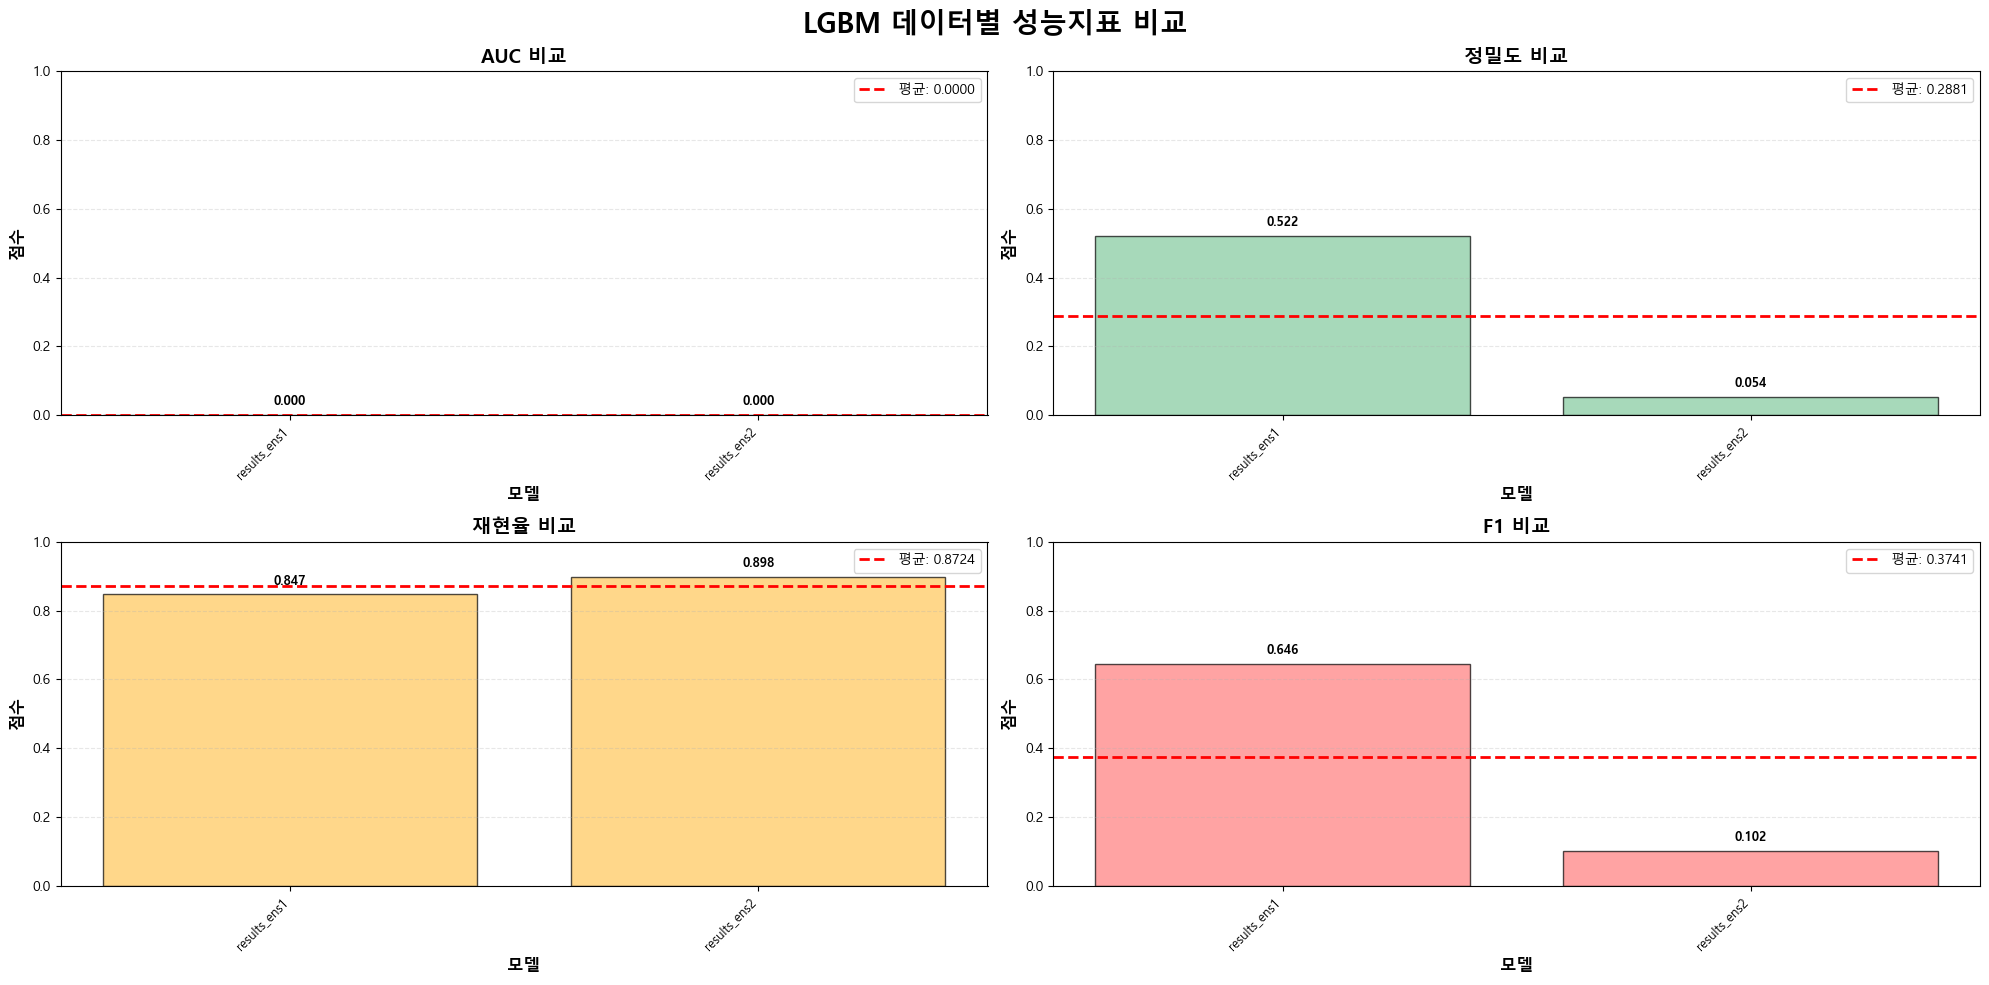


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.0000 (results_ens1)
  최저: 0.0000 (results_ens1)
  평균: 0.0000
  표준편차: 0.0000

[정밀도]
  최고: 0.5220 (results_ens1)
  최저: 0.0542 (results_ens2)
  평균: 0.2881
  표준편차: 0.3308

[재현율]
  최고: 0.8980 (results_ens2)
  최저: 0.8469 (results_ens1)
  평균: 0.8724
  표준편차: 0.0361

[F1]
  최고: 0.6459 (results_ens1)
  최저: 0.1023 (results_ens2)
  평균: 0.3741
  표준편차: 0.3844


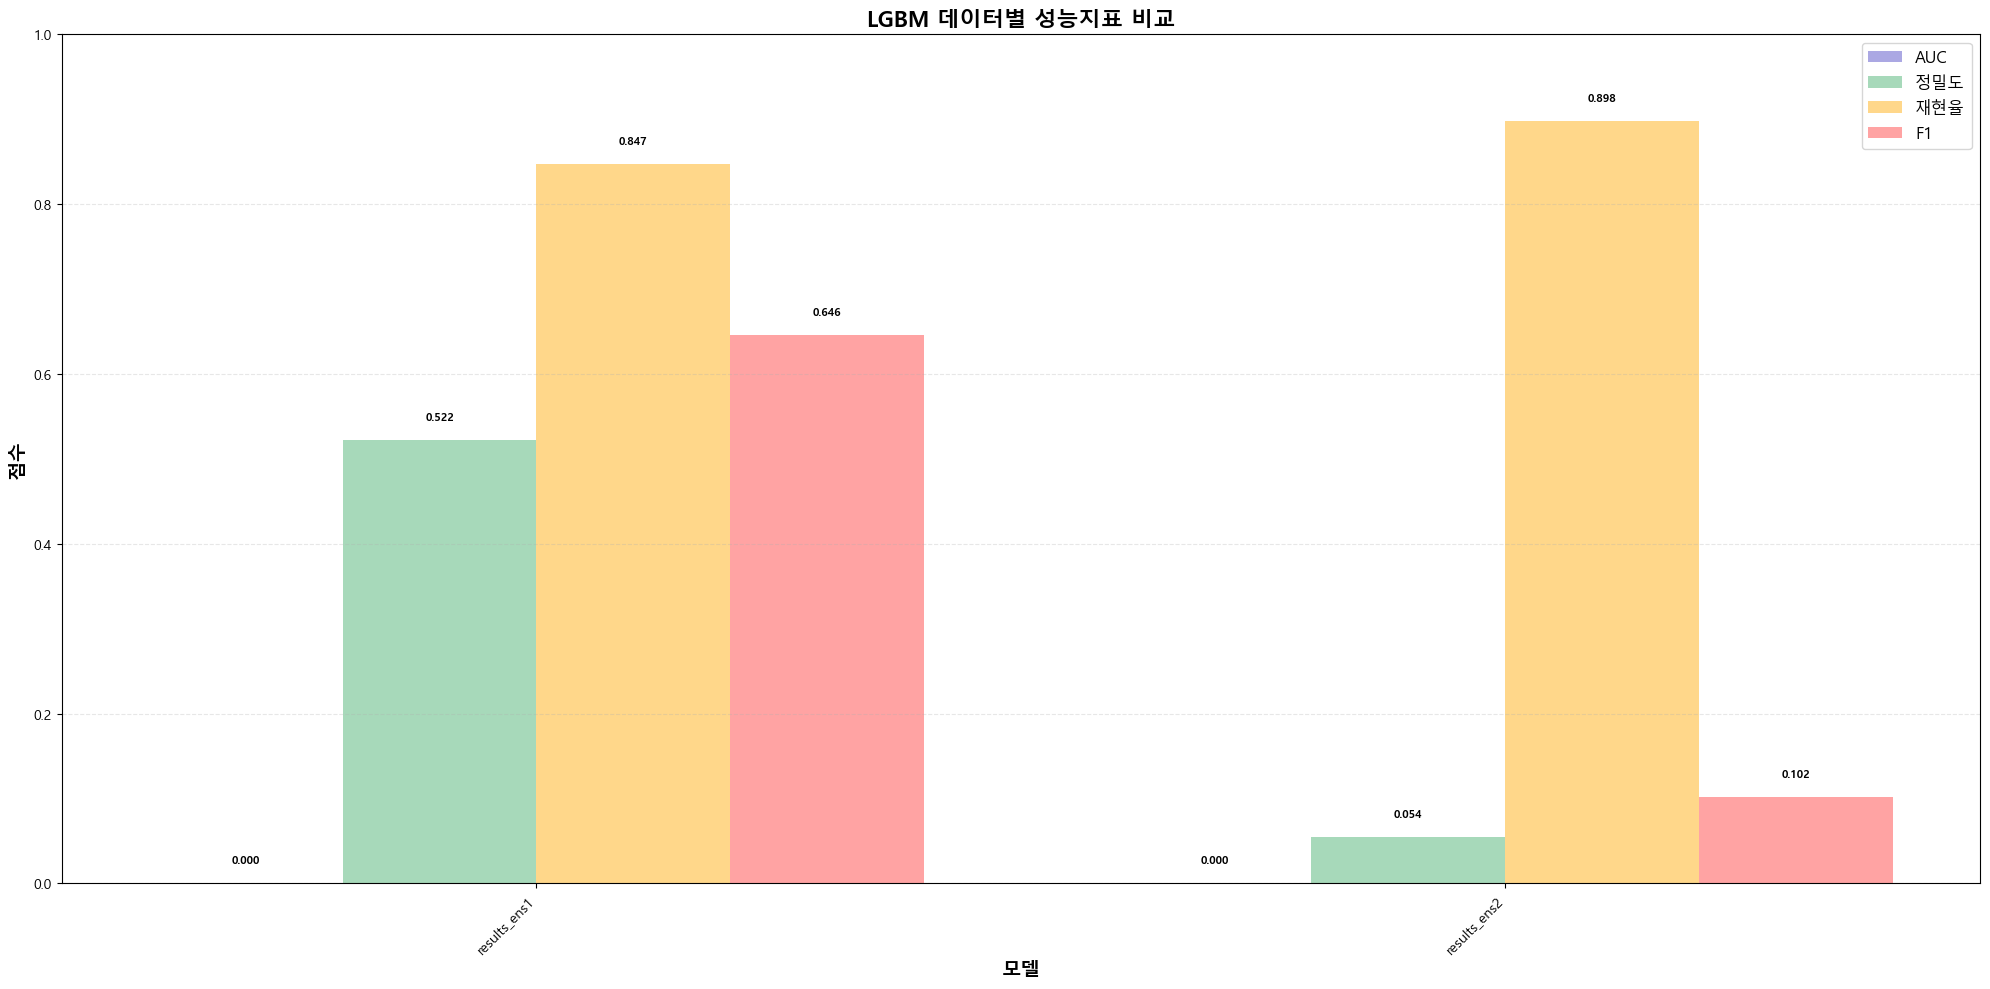


=== F1 Score 기준 상위 5개 모델 ===
[에러 발생] Column 'F1' has dtype object, cannot use method 'nlargest' with this dtype


In [39]:
# 시각화
results = {}
results['results_ens1'] = results_ens1['result_dict']
results['results_ens2'] = results_ens2['result_dict']
mo.model_metrics_graph(results, 'LGBM 데이터별 성능지표 비교')